Use policy gradients to solve OpenAI Gym’s LunarLander-v2
environment.

In [6]:
from tabnanny import verbose
import tensorflow as tf
import numpy as np

In [7]:
@tf.function
def compute_action_and_gradients(observation, model, loss_fn):
    with tf.GradientTape() as tape:
        probabilities = model(observation[tf.newaxis])
        logits = tf.math.log(probabilities + tf.keras.backend.epsilon())
        action = tf.random.categorical(logits, num_samples=1)
        loss = tf.reduce_mean(loss_fn(action, probabilities))
    gradients = tape.gradient(loss, model.trainable_variables)
    return action[0, 0], gradients

def play_one_step(env, obs, loss_fn, model):
    observation_tensor = tf.constant(obs, dtype=tf.float32)
    action, gradients = compute_action_and_gradients(observation_tensor, model, loss_fn)
    obs, reward, done, truncated, info = env.step(action.numpy())
    return obs, reward, done, truncated, gradients

In [8]:
def play_multiple_episodes(episodes, env, n_steps, loss_fn, model):
    all_rewards = []
    all_gradients = []
    for episode in range(episodes):
        episode_rewards = []
        episode_gradients = []
        obs, info = env.reset()
        for step in range(n_steps):
            obs, reward, done, truncated, gradients = play_one_step(env, obs, loss_fn, model)
            episode_rewards.append(reward)
            episode_gradients.append(gradients)
            
            if done or truncated:
                break

        all_rewards.append(episode_rewards)
        all_gradients.append(episode_gradients)

    return all_rewards, all_gradients

In [9]:
def discount_rewards(rewards, discount_factor):
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_factor
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted_rewards = [discount_rewards(rewards, discount_factor)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

In [ ]:
discount_factor = 0.99
optimizer = tf.keras.optimizers.legacy.Nadam(learning_rate=0.0020)
loss_fn = tf.keras.losses.sparse_categorical_crossentropy
input_shape=[8]
n_outputs = 4


model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=input_shape),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_outputs, activation="softmax")
])

In [ ]:
import gymnasium as gym

env = gym.make("LunarLander-v3", render_mode=None)

episodes_per_training = 16
episodes = 5000
steps_per_episode = 10000

mean_rewards_history = []
best_rewards_history = []
worst_rewards_history = []
mean_episode_length_history = []
gradient_norms_history = []

for training_step in range(episodes):
    all_rewards, all_gradients = play_multiple_episodes(
        episodes_per_training, env, steps_per_episode, loss_fn, model
    )

    episode_total_rewards = [sum(episode_rewards) for episode_rewards in all_rewards]
    episode_lengths = [len(episode_rewards) for episode_rewards in all_rewards]

    mean_reward = np.mean(episode_total_rewards)
    best_reward = np.max(episode_total_rewards)
    worst_reward = np.min(episode_total_rewards)
    mean_episode_length = np.mean(episode_lengths)

    mean_rewards_history.append(mean_reward)
    best_rewards_history.append(best_reward)
    worst_rewards_history.append(worst_reward)
    mean_episode_length_history.append(mean_episode_length)

    discounted_and_normalized_rewards = discount_and_normalize_rewards(all_rewards, discount_factor)

    all_mean_grads = []
    for var in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_gradients[episode_index][step][var]
                for episode_index, final_rewards in enumerate(discounted_and_normalized_rewards)
                    for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)

    total_gradient_norm = np.sqrt(sum(
        np.sum(gradient.numpy() ** 2) for gradient in all_mean_grads
    ))
    gradient_norms_history.append(total_gradient_norm)

    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

    if training_step % 10 == 0:
        print(f"Step {training_step:>3d}/{episodes} | "
              f"Mean Reward: {mean_reward:>8.2f} | "
              f"Best: {best_reward:>8.2f} | "
              f"Worst: {worst_reward:>8.2f} | "
              f"Mean Length: {mean_episode_length:>6.1f} | "
              f"Grad Norm: {total_gradient_norm:.4f}")

env.close()

print("\n--- Training Summary ---")
print(f"Final Mean Reward (last 10 steps):  {np.mean(mean_rewards_history[-10:]):.2f}")
print(f"Best Reward Achieved:               {np.max(best_rewards_history):.2f}")
print(f"Worst Reward Achieved:              {np.min(worst_rewards_history):.2f}")
print(f"Final Mean Episode Length:           {np.mean(mean_episode_length_history[-10:]):.1f}")



Step   0/5000 | Mean Reward:  -171.49 | Best:     4.64 | Worst:  -365.11 | Mean Length:   83.9 | Grad Norm: 0.0468
Step  10/5000 | Mean Reward:  -173.14 | Best:   -43.10 | Worst:  -378.83 | Mean Length:   96.1 | Grad Norm: 0.0858
Step  20/5000 | Mean Reward:  -119.42 | Best:    30.04 | Worst:  -253.08 | Mean Length:  101.3 | Grad Norm: 0.0553
Step  30/5000 | Mean Reward:  -135.63 | Best:   -35.09 | Worst:  -337.46 | Mean Length:   91.9 | Grad Norm: 0.0682
Step  40/5000 | Mean Reward:  -111.61 | Best:   -34.89 | Worst:  -209.13 | Mean Length:   95.6 | Grad Norm: 0.0801
Step  50/5000 | Mean Reward:  -119.99 | Best:   -28.72 | Worst:  -359.32 | Mean Length:  125.6 | Grad Norm: 0.0737
Step  60/5000 | Mean Reward:  -110.62 | Best:    26.93 | Worst:  -385.61 | Mean Length:  141.5 | Grad Norm: 0.0665
Step  70/5000 | Mean Reward:   -66.90 | Best:     4.71 | Worst:  -154.34 | Mean Length:  206.2 | Grad Norm: 0.0953
Step  80/5000 | Mean Reward:   -49.59 | Best:    41.57 | Worst:  -245.38 | Mean 

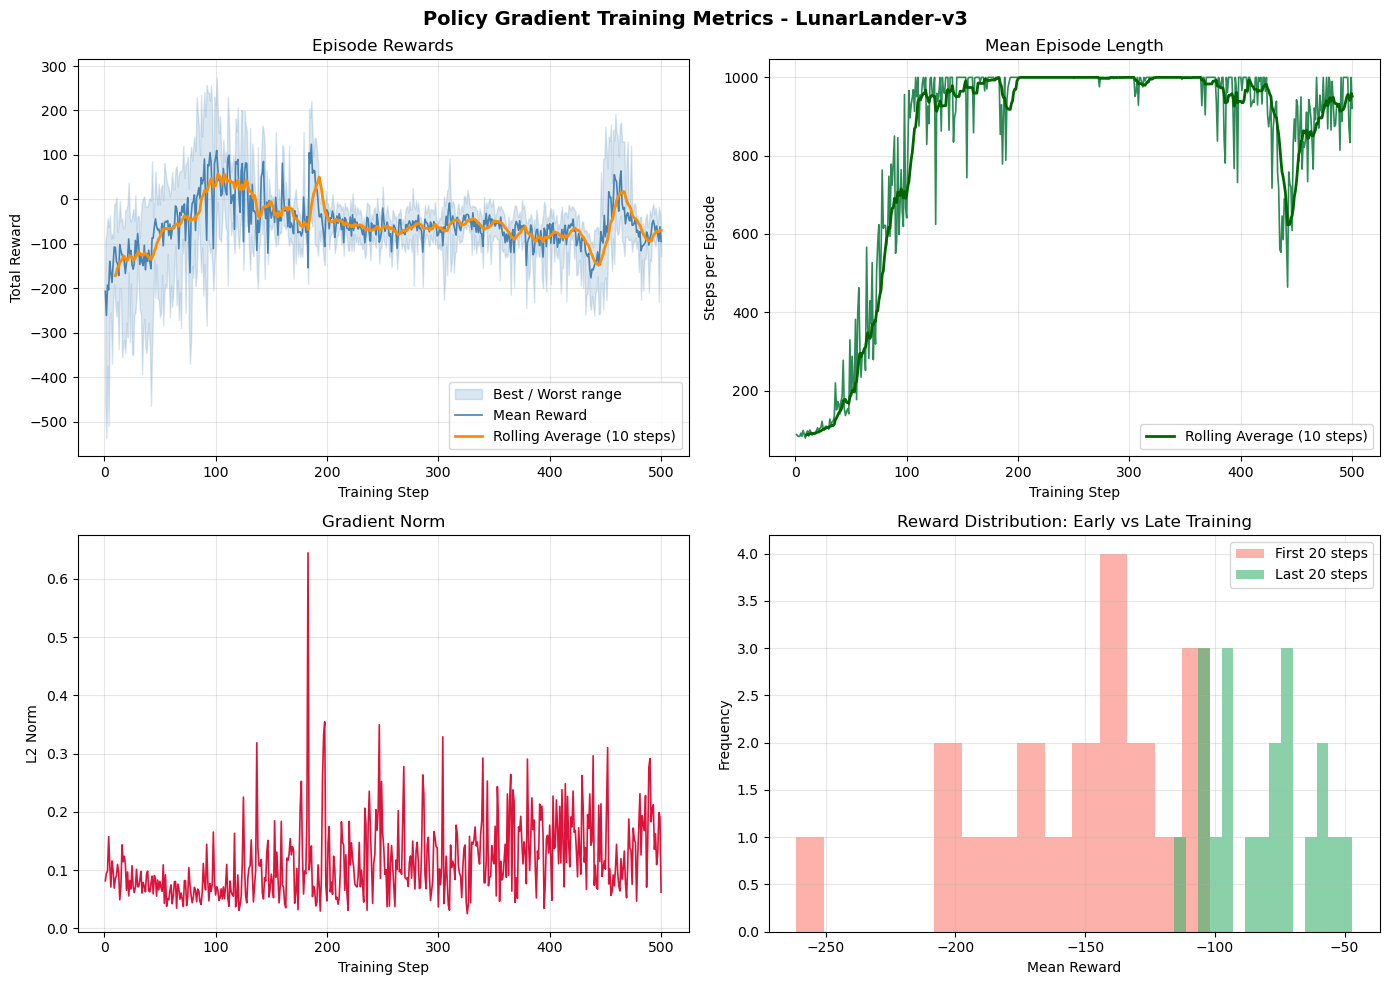

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Policy Gradient Training Metrics - LunarLander-v3", fontsize=14, fontweight="bold")
training_steps = range(1, len(mean_rewards_history) + 1)

# --- Mean Reward with Best/Worst band ---
ax1 = axes[0, 0]
ax1.fill_between(training_steps, worst_rewards_history, best_rewards_history,
                 alpha=0.2, color="steelblue", label="Best / Worst range")
ax1.plot(training_steps, mean_rewards_history, color="steelblue", linewidth=1.2, label="Mean Reward")
window_size = 10
if len(mean_rewards_history) >= window_size:
    rolling_mean = np.convolve(mean_rewards_history, np.ones(window_size) / window_size, mode="valid")
    ax1.plot(range(window_size, len(mean_rewards_history) + 1), rolling_mean,
             color="darkorange", linewidth=2, label=f"Rolling Average ({window_size} steps)")
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Total Reward")
ax1.set_title("Episode Rewards")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# --- Mean Episode Length ---
ax2 = axes[0, 1]
ax2.plot(training_steps, mean_episode_length_history, color="seagreen", linewidth=1.2)
if len(mean_episode_length_history) >= window_size:
    rolling_length = np.convolve(mean_episode_length_history, np.ones(window_size) / window_size, mode="valid")
    ax2.plot(range(window_size, len(mean_episode_length_history) + 1), rolling_length,
             color="darkgreen", linewidth=2, label=f"Rolling Average ({window_size} steps)")
    ax2.legend(loc="lower right")
ax2.set_xlabel("Training Step")
ax2.set_ylabel("Steps per Episode")
ax2.set_title("Mean Episode Length")
ax2.grid(True, alpha=0.3)

# --- Gradient Norm ---
ax3 = axes[1, 0]
ax3.plot(training_steps, gradient_norms_history, color="crimson", linewidth=1.2)
ax3.set_xlabel("Training Step")
ax3.set_ylabel("L2 Norm")
ax3.set_title("Gradient Norm")
ax3.grid(True, alpha=0.3)

# --- Reward Distribution (last 20 vs first 20 training steps) ---
ax4 = axes[1, 1]
first_rewards = []
last_rewards = []
comparison_window = min(20, len(mean_rewards_history) // 2)
for i in range(comparison_window):
    first_rewards.append(mean_rewards_history[i])
    last_rewards.append(mean_rewards_history[-(i + 1)])
ax4.hist(first_rewards, bins=15, alpha=0.6, color="salmon", label=f"First {comparison_window} steps")
ax4.hist(last_rewards, bins=15, alpha=0.6, color="mediumseagreen", label=f"Last {comparison_window} steps")
ax4.set_xlabel("Mean Reward")
ax4.set_ylabel("Frequency")
ax4.set_title("Reward Distribution: Early vs Late Training")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import os

save_directory = "saved_models"
os.makedirs(save_directory, exist_ok=True)

model.save(os.path.join(save_directory, "lunar_lander_policy_gradient.keras"))
print(f"Model saved to {save_directory}/lunar_lander_policy_gradient.keras")

NameError: name 'model' is not defined

In [ ]:
import gymnasium as gym
import tensorflow as tf
import numpy as np
env = gym.make("LunarLander-v3", render_mode="human")

model = tf.keras.models.load_model("saved_models/lunar_lander_policy_gradient.keras")

seed = 4120435
while True:
    obs, info = env.reset()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    obs, info = env.reset(seed=seed)
    while True:
        probas = model(obs[np.newaxis])
        logits = tf.math.log(probas + tf.keras.backend.epsilon())
        action = tf.random.categorical(logits, num_samples=1)
        obs, reward, done, truncated, info = env.step(action[0, 0].numpy())
        if done or truncated:
            break
    break
env.close()